# 一般化バスモデル：マーケティングミックスを考慮した普及予測

## はじめに

前回の記事では、新製品の普及プロセスを説明する**バスモデル**を紹介した。
通常のバスモデルは、「市場環境（価格や広告など）が一定である」という暗黙の仮定を置いている。
しかし現実には、
- 発売直後に大規模な広告キャンペーンを行う
- 途中で値下げ（プライスダウン）を行う

といったマーケティング施策（マーケティングミックス）が普及スピードに大きな影響を与える。

こうした動的な要因をモデルに組み込んだのが、**一般化バスモデル (Generalized Bass Model, GBM)** である。
本記事では、GBMの理論と、Pythonを用いたシミュレーション（値下げや広告キャンペーンの効果検証）について解説する。

## ソースコード

### GitHub
- Jupyter Notebook形式のファイルは[こちら](https://github.com/hiroshi0530/wa-src/blob/master/article/stats/03/03_nb.ipynb)

### Google Colaboratory
- Google Colaboratory で実行する場合は[こちら](https://colab.research.google.com/github/hiroshi0530/wa-src/blob/master/article/stats/03/03_nb.ipynb)

## 実行環境
OSはmacOSである。LinuxやUnixのコマンドとはオプションが異なることに注意されたい。

In [1]:
!sw_vers

ProductName:		macOS
ProductVersion:		15.5
BuildVersion:		24F74


In [2]:
!python -V

Python 3.14.0


必要なライブラリをインポートする。
GBMは解析的に解くのが難しいケース（マーケティング変数が複雑に変化する場合）があるため、今回は数値積分（`odeint`）を用いてシミュレーションを行う。

In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# グラフのスタイル設定
plt.style.use('seaborn-v0_8-darkgrid')

## 1. 一般化バスモデル (GBM) の理論

Bass, Krishnan, & Jain (1994) によって提案された一般化バスモデルは、通常のバスモデルに**現在のマーケティング努力**を表す項 $x(t)$ を追加したものである。

### 1.1 微分方程式

$$
\frac{dN(t)}{dt} = \left( p + q \frac{N(t)}{M} \right) (M - N(t)) \cdot x(t)
$$

ここで $x(t)$ は、マーケティング変数の効果を表す関数で、以下のように定義される。

$$
x(t) = 1 + \beta_P \frac{P'(t)}{P(t)} + \beta_A \frac{A'(t)}{A(t)}
$$

もっと単純には、「基準となるマーケティング努力に対する、現在の努力の倍率」と考えればよいだろう。
- $x(t) = 1$: 通常の状態（標準バスモデルと同じ）
- $x(t) > 1$: 積極的な施策（値下げ、広告増）により普及が加速
- $x(t) < 1$: 逆風（値上げ、広告減）により普及が減速

## 2. Pythonによるシミュレーション

それでは、いくつかのシナリオで普及プロセスがどう変化するかシミュレーションしてみる。

### 2.1 モデルの実装

数値積分を行うための関数を定義する。

In [4]:
def gbm_ode(N, t, M, p, q, marketing_func):
    """一般化バスモデルの微分方程式"""
    x_t = marketing_func(t)
    dNdt = (p + q * N / M) * (M - N) * x_t
    return dNdt

def solve_gbm(M, p, q, marketing_func, t_points):
    """数値積分を実行してN(t)とn(t)を返す"""
    # 初期値 N(0) = 0
    N0 = 0

    # odeintで累積採用者数 N(t) を計算
    N_sol = odeint(gbm_ode, N0, t_points, args=(M, p, q, marketing_func))
    N_t = N_sol.flatten()

    # 新規採用者数 n(t) を計算（微分方程式に代入）
    # 注意: odeintの結果は離散点なので、その点での傾きを計算
    n_t = np.array([gbm_ode(n, t, M, p, q, marketing_func) for n, t in zip(N_t, t_points)])

    return N_t, n_t

### 2.2 シナリオ設定

以下の3つのシナリオを比較する。

1. **Base Case**: $x(t) = 1$ （通常のバスモデル）
2. **Price Drop**: $t=10$ で価格を下げ、普及が加速する ($x(t)$ が 1.0 から 1.5 に恒久的に上昇)
3. **Ad Campaign**: $t=5$ から $t=8$ の間だけ強力な広告を打つ ($x(t)$ が一時的に 2.0 になる)

In [5]:
# パラメータ
M = 10000
p = 0.01
q = 0.3
t_max = 30
t_points = np.linspace(0, t_max, 300)

# マーケティング関数 x(t) の定義

def x_base(t):
    return 1.0

def x_price_drop(t):
    # t=10 以降、効果が1.5倍になる
    return 1.5 if t >= 10 else 1.0

def x_ad_campaign(t):
    # t=5~8 の間、効果が2.0倍になる
    return 2.0 if 5 <= t <= 8 else 1.0

# シミュレーション実行
results = {}
scenarios = {
    'Base Case': x_base,
    'Price Drop (t>=10)': x_price_drop,
    'Ad Campaign (t=5-8)': x_ad_campaign
}

for name, func in scenarios.items():
    N, n = solve_gbm(M, p, q, func, t_points)
    results[name] = (N, n)

### 2.3 結果の可視化

各シナリオの新規採用者数 $n(t)$ の推移をプロットする。

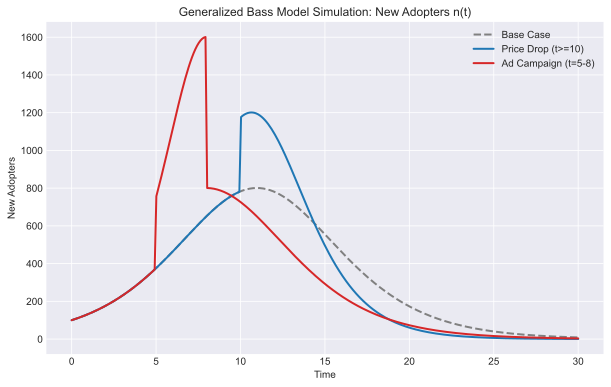

In [6]:
plt.figure(figsize=(10, 6))

colors = ['gray', 'tab:blue', 'tab:red']
linestyles = ['--', '-', '-']

for (name, (N, n)), color, ls in zip(results.items(), colors, linestyles):
    plt.plot(t_points, n, label=name, color=color, linestyle=ls, lw=2)

plt.title('Generalized Bass Model Simulation: New Adopters n(t)')
plt.xlabel('Time')
plt.ylabel('New Adopters')
plt.legend()
plt.show()

### 考察

- **Base Case (灰色)**: 滑らかな釣鐘型を描く。
- **Price Drop (青色)**: $t=10$ で $x(t)$ が上昇した瞬間、採用者数が跳ね上がり、その後もベースより高い水準で推移してピークが早まる。
- **Ad Campaign (赤色)**: キャンペーン期間中 ($t=5\sim8$) だけ急激に採用が増えるが、キャンペーン終了後は反動でベースよりも下がることがある（需要の先食い）。

## 結論

一般化バスモデルを用いることで、単なる自然な普及だけでなく、企業の戦略的なアクションが市場に与えるインパクトを定量的に評価・予測することが可能になる。

実際のビジネスでは、過去の販売データと価格・広告費の推移データを用いて $p, q$ およびマーケティング変数の弾力性を推定し、将来の施策立案に役立てることができる。